# Phase 1 — Scaleup Image-Only Classifier (v2 — All Fixes)
## PneumoFusionNet | MIMIC-CXR PA Cohort (Scaled-Up Dataset: ~3,763 images)

### Fixes applied over the original Scaleup notebook:
1. **No Horizontal Flip** — Disabled to respect standard clinical chest anatomy (heart laterality)
2. **Stratified Split** — `train_test_split` now stratifies by per-subject majority label
3. **Resume Bug Fix** — `best_state` weights are now saved/loaded correctly from checkpoint
4. **Rotation reduced** — From 10° to 5° (matches real-world patient tilt)
5. **AMP Mixed Precision** — `torch.cuda.amp` enabled for ~30–40% faster training
6. **Bbox merging** — Uses top-2 contours to capture both lungs when mediastinum splits them

### Architecture:
- **DenseNet121** backbone with MIMIC-specific weights (`densenet121-res224-mimic_nb`)
- **CBAM attention** (Channel + Spatial)
- **Otsu-based lung bbox detection** at 320×320 resolution
- **Label smoothing (0.1)**, **TTA (10 views)**, **CosineAnnealingWarmRestarts**
- **Patient-level splitting** (stratified 70/15/15 by `subject_id`) to prevent data leakage

In [1]:
# --- CELL 0: Imports & Reproducibility ---
import os, sys, random, warnings, json, copy, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchxrayvision as xrv

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB')
print(f'PyTorch : {torch.__version__}')
print(f'XRV     : {xrv.__version__}')

Device  : cuda
GPU     : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM    : 4.29 GB
PyTorch : 2.5.1+cu121
XRV     : 1.4.0


In [2]:
# --- CELL 1: Configuration ---
BASE_DIR   = r'c:\\2026\\PneumoFusionNet\\mimic\\main\\dataset'
CSV_PATH   = os.path.join(BASE_DIR, 'mimic_paired_dataset.csv')
SAVE_DIR   = os.path.join(BASE_DIR, 'outputs', 'Phase_1_Scaleup_PA_v2')
os.makedirs(SAVE_DIR, exist_ok=True)

# Backbone: MIMIC-specific weights
BACKBONE_WEIGHTS = 'densenet121-res224-mimic_nb'

# Higher resolution for subtle opacity patterns
IMG_SIZE   = 320

# Training hyperparameters
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
BATCH_SIZE   = 16
LR           = 1e-4
EPOCHS       = 40
PATIENCE     = 10
TTA_VIEWS    = 10
LABEL_SMOOTH = 0.1
CLASSES      = ['NORMAL', 'PNEUMONIA']

# Tuned CLAHE
CLAHE_CLIP  = 3.0
CLAHE_TILE  = (4,4)

# AMP Mixed Precision (FIX #5)
USE_AMP = torch.cuda.is_available()

print(f'Backbone weights : {BACKBONE_WEIGHTS}')
print(f'Image resolution : {IMG_SIZE}x{IMG_SIZE}')
print(f'Label smoothing  : {LABEL_SMOOTH}')
print(f'Mixed Precision  : {USE_AMP}')
print(f'Save dir         : {SAVE_DIR}')

Backbone weights : densenet121-res224-mimic_nb
Image resolution : 320x320
Label smoothing  : 0.1
Mixed Precision  : True
Save dir         : c:\\2026\\PneumoFusionNet\\mimic\\main\\dataset\outputs\Phase_1_Scaleup_PA_v2


In [3]:
# --- CELL 2: Data Loading & Label Assignment ---
df = pd.read_csv(CSV_PATH)

def resolve_path(p):
    if pd.isna(p) or str(p).strip() == '': return ''
    p = str(p).replace('/', os.sep)
    return p if os.path.isabs(p) else os.path.join(BASE_DIR, p)

df['image_path'] = df['image_path'].apply(resolve_path)
df['label'] = np.select(
    [df['pneumonia_label'].eq(1.0), df['no_finding_label'].eq(1.0)],
    [1, 0], default=-1
)
df = df[(df['label'] >= 0) & df['view_position'].eq('PA')].copy()
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)

print(f'Total usable PA rows : {len(df)}')
print(df['label'].value_counts().rename({0:'Normal',1:'Pneumonia'}))

Total usable PA rows : 3763
Pneumonia    1891
Normal       1872
Name: label, dtype: int64


In [4]:
# --- CELL 3: Otsu-based Lung Bbox Detection (FIX #6: merge top-2 contours) ---
def detect_lung_bbox_otsu(image_path, margin=0.05):
    """
    Detect lung bounding box using Otsu thresholding + morphological operations.
    FIX #6: Uses top-2 contours and merges their bounding boxes so both lungs
    are captured even when the mediastinum splits the binary mask.
    Returns dict with x_min, y_min, x_max, y_max, or None if detection fails.
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    H, W = img.shape

    # CLAHE + Gaussian blur for better thresholding
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_c = clahe.apply(img)
    blurred = cv2.GaussianBlur(img_c, (5,5), 0)

    # Otsu threshold
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological closing to fill holes
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20,20))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    # Find contours
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return None

    # FIX #6: Use top-2 largest contours and merge their bounding boxes
    # This captures both lungs even when mediastinum splits the mask
    min_area = H * W * 0.05  # each contour must be at least 5% of image
    valid = [c for c in contours if cv2.contourArea(c) >= min_area]
    if not valid:
        return None

    # Sort by area descending, take top 2
    valid = sorted(valid, key=cv2.contourArea, reverse=True)[:2]

    # Check total area covers at least 10% of image
    total_area = sum(cv2.contourArea(c) for c in valid)
    if total_area < (H * W * 0.10):
        return None

    # Merge bounding boxes from all valid contours
    rects = [cv2.boundingRect(c) for c in valid]
    x = min(r[0] for r in rects)
    y = min(r[1] for r in rects)
    x2 = max(r[0] + r[2] for r in rects)
    y2 = max(r[1] + r[3] for r in rects)

    # Add margin
    mx = int(W * margin); my = int(H * margin)
    x_min = max(0, x - mx)
    y_min = max(0, y - my)
    x_max = min(W, x2 + mx)
    y_max = min(H, y2 + my)
    return {'x_min':x_min,'y_min':y_min,'x_max':x_max,'y_max':y_max}

# Check for cached bboxes from prior runs
bbox_cache_path = os.path.join(SAVE_DIR, 'lung_bboxes_scaleup_v2.csv')
if os.path.exists(bbox_cache_path):
    old_bbox_df = pd.read_csv(bbox_cache_path)
    bbox_lookup = old_bbox_df.set_index('image_path').to_dict('index')
    print(f'Loaded {len(bbox_lookup)} cached bboxes from prior run')
else:
    bbox_lookup = {}
    print('No cached bboxes found, will detect from scratch')

missing_paths = [row.image_path for _, row in df.iterrows() if row.image_path not in bbox_lookup]
print(f'Images needing new bbox detection: {len(missing_paths)}')

detected, failed = 0, 0
for path in tqdm(missing_paths, desc='Detecting lung bboxes'):
    bb = detect_lung_bbox_otsu(path)
    if bb:
        bbox_lookup[path] = bb
        detected += 1
    else:
        failed += 1

print(f'Detected  : {detected}')
print(f'Failed    : {failed} (will use full image)')
print(f'Total bbox coverage: {len(bbox_lookup)}/{len(df)} ({len(bbox_lookup)/len(df)*100:.1f}%)')

# Save/update bbox cache
bbox_rows = [{'image_path':k,'x_min':v['x_min'],'y_min':v['y_min'],
               'x_max':v['x_max'],'y_max':v['y_max']} for k,v in bbox_lookup.items()]
pd.DataFrame(bbox_rows).to_csv(bbox_cache_path, index=False)
print(f'Saved bbox cache: {bbox_cache_path}')

No cached bboxes found, will detect from scratch
Images needing new bbox detection: 3763


Detecting lung bboxes:   0%|          | 0/3763 [00:00<?, ?it/s]

Detected  : 3763
Failed    : 0 (will use full image)
Total bbox coverage: 3763/3763 (100.0%)
Saved bbox cache: c:\\2026\\PneumoFusionNet\\mimic\\main\\dataset\outputs\Phase_1_Scaleup_PA_v2\lung_bboxes_scaleup_v2.csv


In [5]:
# --- CELL 4: Patient-Level Stratified Train / Val / Test Split (FIX #1) ---
# FIX #1: Stratify by per-subject majority label to ensure balanced class
# distribution across train/val/test splits.
subject_ids = df['subject_id'].unique()

# Compute majority label per subject for stratification
subject_label_map = df.groupby('subject_id')['label'].agg(lambda x: x.mode()[0])
subject_labels = subject_label_map[subject_ids].values

train_val_sids, test_sids = train_test_split(
    subject_ids, test_size=0.15, random_state=SEED,
    stratify=subject_labels                          # <-- FIX #1: stratified
)
val_frac = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
train_val_labels = subject_label_map[train_val_sids].values
train_sids, val_sids = train_test_split(
    train_val_sids, test_size=val_frac, random_state=SEED,
    stratify=train_val_labels                        # <-- FIX #1: stratified
)

train_df = df[df['subject_id'].isin(train_sids)].reset_index(drop=True)
val_df   = df[df['subject_id'].isin(val_sids)].reset_index(drop=True)
test_df  = df[df['subject_id'].isin(test_sids)].reset_index(drop=True)

for name, split in [('Train',train_df),('Val',val_df),('Test',test_df)]:
    n0=(split['label']==0).sum(); n1=(split['label']==1).sum()
    ratio = n1/(n0+n1)*100
    print(f'{name:5s}: {len(split):5d}  (Normal={n0}, Pneumonia={n1}, Pneumonia%={ratio:.1f}%)')

Train:  2642  (Normal=1318, Pneumonia=1324, Pneumonia%=50.1%)
Val  :   566  (Normal=276, Pneumonia=290, Pneumonia%=51.2%)
Test :   555  (Normal=278, Pneumonia=277, Pneumonia%=49.9%)


In [6]:
# --- CELL 5: Compute Dataset Mean & Std (for 320x320) ---
sample_paths = train_df['image_path'].sample(min(300, len(train_df)), random_state=SEED).tolist()
clahe_stat   = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)
pixel_vals   = []
for p in tqdm(sample_paths, desc='Computing stats'):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    img = clahe_stat.apply(img)
    bb  = bbox_lookup.get(p, None)
    if bb and bb.get('x_max',0)>0:
        img = img[bb['y_min']:bb['y_max'], bb['x_min']:bb['x_max']]
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
    pixel_vals.append(img.flatten())
all_pixels = np.concatenate(pixel_vals)
MEAN = [float(all_pixels.mean())]
STD  = [float(all_pixels.std())]
print(f'Computed MEAN: {MEAN[0]:.4f}  STD: {STD[0]:.4f}')

Computing stats:   0%|          | 0/300 [00:00<?, ?it/s]

Computed MEAN: 0.5006  STD: 0.2814


In [7]:
# --- CELL 6: Enhanced Dataset Class (FIX #3: rotation reduced to 5°) ---
class EnhancedCXRDataset(Dataset):
    def __init__(self, df, bbox_lookup, transform, clahe_clip=CLAHE_CLIP, clahe_tile=CLAHE_TILE):
        self.df          = df.reset_index(drop=True)
        self.bbox_lookup = bbox_lookup
        self.transform   = transform
        self.clahe       = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=clahe_tile)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row.image_path, cv2.IMREAD_GRAYSCALE)
        if img is None: img = np.zeros((IMG_SIZE,IMG_SIZE), dtype=np.uint8)
        # Tuned CLAHE
        img = self.clahe.apply(img)
        # Bbox crop
        bb = self.bbox_lookup.get(row.image_path, None)
        if bb and bb.get('x_max',0)>0:
            img = img[bb['y_min']:bb['y_max'], bb['x_min']:bb['x_max']]
        img = self.transform(Image.fromarray(img))
        return img, int(row.label)
    def set_transform(self, t): self.transform = t

# Transforms (320x320)
# FIX #1: Horizontal flip removed (anatomical laterality)
# FIX #3: Rotation reduced from 10° to 5° (clinical realism)
val_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # No horizontal flip — protects anatomical left/right integrity
    transforms.RandomRotation(5),                                    # FIX #3: was 10
    transforms.RandomAffine(degrees=0, translate=(0.05,0.05)),
    transforms.ColorJitter(brightness=0.25, contrast=0.25),
    transforms.RandomAutocontrast(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# TTA transforms (10 views) — no horizontal flipping
tta_tfms = [
    val_tfm,
    transforms.Compose([transforms.Resize((int(IMG_SIZE*1.05),int(IMG_SIZE*1.05))),
                         transforms.CenterCrop(IMG_SIZE),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((int(IMG_SIZE*1.1),int(IMG_SIZE*1.1))),
                         transforms.CenterCrop(IMG_SIZE),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.RandomRotation(degrees=(3,3)),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.RandomRotation(degrees=(-3,-3)),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.ColorJitter(brightness=0.2),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.ColorJitter(contrast=0.2),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((int(IMG_SIZE*1.05),int(IMG_SIZE*1.05))),
                         transforms.RandomCrop(IMG_SIZE),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.RandomAutocontrast(p=1.0),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.RandomEqualize(p=1.0),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
]

train_ds = EnhancedCXRDataset(train_df, bbox_lookup, train_tfm)
val_ds   = EnhancedCXRDataset(val_df,   bbox_lookup, val_tfm)
test_ds  = EnhancedCXRDataset(test_df,  bbox_lookup, val_tfm)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train batches: 166 | Val: 36 | Test: 35


In [8]:
# --- CELL 7: Model Architecture (DenseNet121 + CBAM) ---
class ChannelAttention(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        self.avg=nn.AdaptiveAvgPool2d(1); self.max=nn.AdaptiveMaxPool2d(1)
        self.mlp=nn.Sequential(nn.Conv2d(c,c//r,1,bias=False),nn.ReLU(True),nn.Conv2d(c//r,c,1,bias=False))
        self.sig=nn.Sigmoid()
    def forward(self,x): return x*self.sig(self.mlp(self.avg(x))+self.mlp(self.max(x)))

class SpatialAttention(nn.Module):
    def __init__(self,k=7):
        super().__init__()
        self.conv=nn.Conv2d(2,1,k,padding=k//2,bias=False); self.sig=nn.Sigmoid()
    def forward(self,x):
        return x*self.sig(self.conv(torch.cat([x.mean(1,keepdim=True),x.max(1,keepdim=True)[0]],1)))

class CBAM(nn.Module):
    def __init__(self,c,r=16):
        super().__init__()
        self.ca=ChannelAttention(c,r); self.sa=SpatialAttention()
    def forward(self,x): return self.sa(self.ca(x))

class ScaleupCXRModel(nn.Module):
    def __init__(self, backbone_weights=BACKBONE_WEIGHTS, num_classes=2):
        super().__init__()
        xrv_m = xrv.models.DenseNet(weights=backbone_weights)
        self.features = xrv_m.features
        self.cbam     = CBAM(1024, r=16)
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.dropout  = nn.Dropout(0.4)
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
        # Only freeze denseblock1 + transition1
        freeze_prefixes = ('features.conv0','features.norm0','features.relu0',
                           'features.pool0','features.denseblock1','features.transition1')
        for name, param in self.features.named_parameters():
            pname = 'features.' + name
            if any(pname.startswith(pfx) for pfx in freeze_prefixes):
                param.requires_grad = False

        total   = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'[Model] Total params     : {total:,}')
        print(f'[Model] Trainable params : {trainable:,} ({trainable/total*100:.1f}%)')

    def forward(self, x):
        f = F.relu(self.features(x), inplace=True)
        f = self.cbam(f)
        f = self.dropout(self.pool(f).flatten(1))
        return self.classifier(f)

    def get_features(self, x):
        f = F.relu(self.features(x), inplace=True)
        f = self.cbam(f)
        return self.pool(f).flatten(1)  # (B, 1024) for downstream fusion

print(f'Loading backbone: {BACKBONE_WEIGHTS} ...')
model = ScaleupCXRModel().to(DEVICE)

Loading backbone: densenet121-res224-mimic_nb ...
[Model] Total params     : 7,670,500
[Model] Trainable params : 7,298,916 (95.2%)


In [9]:
# --- CELL 8: Training Setup (FIX #5: AMP scaler) ---
n0=(train_df['label']==0).sum(); n1=(train_df['label']==1).sum()
weight = torch.tensor([n1/(n0+n1), n0/(n0+n1)], dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weight, label_smoothing=LABEL_SMOOTH)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

# FIX #5: AMP GradScaler for mixed-precision training
scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train(train)
    total_loss, all_probs, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train: optimizer.zero_grad()

            # FIX #5: AMP autocast for forward pass
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                logits = model(imgs)
                loss   = criterion(logits, labels)

            if train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()

            probs = F.softmax(logits.detach().float(), dim=1)[:,1].cpu().numpy()
            total_loss += loss.item()*labels.size(0)
            all_probs.extend(probs); all_labels.extend(labels.cpu().tolist())
    acc = accuracy_score(all_labels,[1 if p>=0.5 else 0 for p in all_probs])
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels))>1 else 0.5
    return total_loss/len(all_labels), acc, auc

print('Training setup complete.')
print(f'Label smoothing  : {LABEL_SMOOTH}')
print(f'LR               : {LR}')
print(f'Scheduler        : CosineAnnealingWarmRestarts (T_0=10)')
print(f'AMP Scaler       : {USE_AMP}')

Training setup complete.
Label smoothing  : 0.1
LR               : 0.0001
Scheduler        : CosineAnnealingWarmRestarts (T_0=10)
AMP Scaler       : True


In [10]:
# --- CELL 9: Training Loop (FIX #2: best_state saved in checkpoint, FIX #4: scheduler.step(epoch)) ---
ckpt_path = os.path.join(SAVE_DIR, 'latest_checkpoint_scaleup_v2.pth')
start_epoch = 1

best_auc, best_state, patience_cnt = 0.0, None, 0
history = {'train_loss':[],'val_loss':[],'train_auc':[],'val_auc':[],'lr':[]}

if os.path.exists(ckpt_path):
    print(f'>> Found checkpoint: {ckpt_path}. Resuming training...')
    ckpt = torch.load(ckpt_path, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    if 'scaler_state' in ckpt and USE_AMP:
        scaler.load_state_dict(ckpt['scaler_state'])
    start_epoch = ckpt['epoch'] + 1
    best_auc = ckpt['best_auc']
    history = ckpt['history']
    patience_cnt = ckpt['patience_cnt']
    # FIX #2: Load the actual best model weights, not the latest epoch weights
    if 'best_state' in ckpt and ckpt['best_state'] is not None:
        best_state = ckpt['best_state']
        print(f'>> Loaded best_state from checkpoint (best AUC: {best_auc:.4f})')
    else:
        best_state = copy.deepcopy(model.state_dict())
        print(f'>> WARNING: No best_state in checkpoint, using latest model weights')
    print(f'>> Resuming from Epoch {start_epoch} (Best AUC so far: {best_auc:.4f})')

t0 = time.time()
for epoch in range(start_epoch, EPOCHS+1):
    ep_t = time.time()
    tr_loss, tr_acc, tr_auc = run_epoch(model, train_loader, optimizer, criterion, DEVICE, train=True)
    va_loss, va_acc, va_auc = run_epoch(model, val_loader,   optimizer, criterion, DEVICE, train=False)
    scheduler.step(epoch)  # FIX #4: pass epoch explicitly
    cur_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_auc'].append(tr_auc);   history['val_auc'].append(va_auc)
    history['lr'].append(cur_lr)

    marker = ''
    if va_auc > best_auc:
        best_auc   = va_auc
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, os.path.join(SAVE_DIR,'best_model_scaleup_v2.pth'))
        patience_cnt = 0; marker = ' <-- best'
    else:
        patience_cnt += 1

    # FIX #2: Save best_state inside checkpoint so it survives resume
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'best_state': best_state,                    # <-- FIX #2
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'scaler_state': scaler.state_dict(),         # <-- FIX #5: save AMP state
        'best_auc': best_auc,
        'history': history,
        'patience_cnt': patience_cnt
    }, ckpt_path)
    elapsed  = time.time() - t0
    ep_time  = time.time() - ep_t
    remaining= ep_time * (EPOCHS - epoch)
    if epoch % 5 == 0 or marker:
        print(f'Ep {epoch:03d}/{EPOCHS} | tr_loss={tr_loss:.4f} tr_auc={tr_auc:.4f} '
              f'| val_auc={va_auc:.4f} val_acc={va_acc:.3f} '
              f'| lr={cur_lr:.1e} | {ep_time:.0f}s/ep | ETA:{remaining/60:.0f}m{marker}')

    if patience_cnt >= PATIENCE:
        print(f'Early stop at epoch {epoch}.'); break

print(f'Training complete in {(time.time()-t0)/60:.1f} min')
print(f'Best Val AUC: {best_auc:.4f}')

Ep 001/40 | tr_loss=0.6348 tr_auc=0.7185 | val_auc=0.8059 val_acc=0.721 | lr=9.8e-05 | 235s/ep | ETA:152m <-- best
Ep 002/40 | tr_loss=0.6104 tr_auc=0.7571 | val_auc=0.8136 val_acc=0.735 | lr=9.1e-05 | 264s/ep | ETA:167m <-- best
Ep 004/40 | tr_loss=0.6033 tr_auc=0.7648 | val_auc=0.8146 val_acc=0.719 | lr=6.6e-05 | 251s/ep | ETA:151m <-- best
Ep 005/40 | tr_loss=0.5978 tr_auc=0.7716 | val_auc=0.8177 val_acc=0.733 | lr=5.1e-05 | 258s/ep | ETA:150m <-- best
Ep 006/40 | tr_loss=0.5939 tr_auc=0.7780 | val_auc=0.8180 val_acc=0.731 | lr=3.5e-05 | 256s/ep | ETA:145m <-- best
Ep 007/40 | tr_loss=0.5991 tr_auc=0.7734 | val_auc=0.8210 val_acc=0.723 | lr=2.1e-05 | 277s/ep | ETA:152m <-- best
Ep 008/40 | tr_loss=0.5943 tr_auc=0.7763 | val_auc=0.8227 val_acc=0.721 | lr=1.0e-05 | 280s/ep | ETA:149m <-- best
Ep 009/40 | tr_loss=0.5900 tr_auc=0.7822 | val_auc=0.8229 val_acc=0.721 | lr=3.4e-06 | 268s/ep | ETA:139m <-- best
Ep 010/40 | tr_loss=0.5885 tr_auc=0.7851 | val_auc=0.8233 val_acc=0.719 | lr=1.0

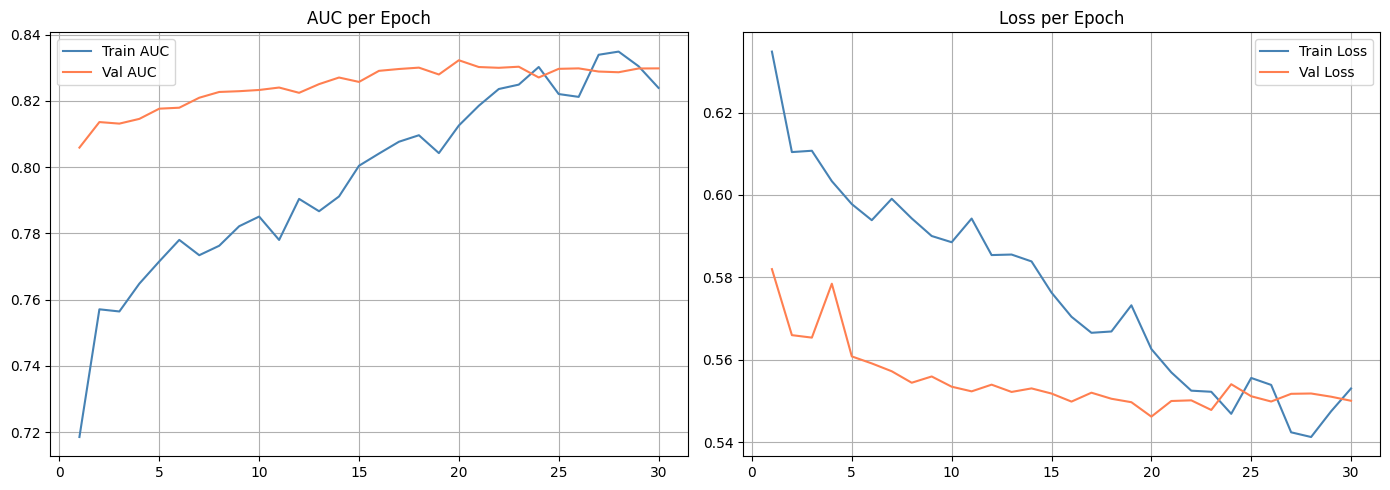

In [11]:
# --- CELL 10: Training Curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['train_auc'])+1)

axes[0].plot(epochs_range, history['train_auc'], label='Train AUC', color='steelblue')
axes[0].plot(epochs_range, history['val_auc'],   label='Val AUC',   color='coral')
axes[0].set_title('AUC per Epoch'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_range, history['train_loss'], label='Train Loss', color='steelblue')
axes[1].plot(epochs_range, history['val_loss'],   label='Val Loss',   color='coral')
axes[1].set_title('Loss per Epoch'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves_scaleup_v2.png'), dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# --- CELL 11: Test Evaluation with TTA (10 views) ---
model.load_state_dict(best_state)
model.eval()

all_tta_probs = []
for tfm in tqdm(tta_tfms, desc='TTA views'):
    test_ds.set_transform(tfm)
    probs_view = []
    with torch.no_grad():
        for imgs, _ in test_loader:
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                logits = model(imgs.to(DEVICE))
            probs_view.extend(F.softmax(logits.float(), dim=1)[:,1].cpu().numpy())
    all_tta_probs.append(probs_view)

tta_probs  = np.mean(all_tta_probs, axis=0)
true_labels = test_df['label'].values

# Clinical threshold: maximise Sensitivity >= 90%
fpr, tpr, thresholds = roc_curve(true_labels, tta_probs)
high_sens = [(t, tpr[i], 1-fpr[i]) for i,t in enumerate(thresholds) if tpr[i] >= 0.90]
best_thresh = max(high_sens, key=lambda x: x[2])[0] if high_sens else 0.5

# Also compute Youden's J for comparison
j_scores = tpr - fpr
youden_idx = np.argmax(j_scores)
youden_thresh = thresholds[youden_idx]

preds = (tta_probs >= best_thresh).astype(int)
auc   = roc_auc_score(true_labels, tta_probs)
acc   = accuracy_score(true_labels, preds)
f1    = f1_score(true_labels, preds)
cm    = confusion_matrix(true_labels, preds)
tn, fp, fn, tp = cm.ravel()
sens  = tp / (tp + fn)
spec  = tn / (tn + fp)

print('='*55)
print(f'  Test Results (TTA={TTA_VIEWS}, threshold={best_thresh:.3f})')
print('='*55)
print(f'  AUC         : {auc:.4f}')
print(f'  Accuracy    : {acc:.4f}')
print(f'  F1-Score    : {f1:.4f}')
print(f'  Sensitivity : {sens:.4f}  (Recall for Pneumonia)')
print(f'  Specificity : {spec:.4f}  (Recall for Normal)')
print(f'  Youden Thr  : {youden_thresh:.3f}')
print('='*55)
print(classification_report(true_labels, preds, target_names=CLASSES))

TTA views:   0%|          | 0/10 [00:00<?, ?it/s]

  Test Results (TTA=10, threshold=0.288)
  AUC         : 0.7900
  Accuracy    : 0.6432
  F1-Score    : 0.7163
  Sensitivity : 0.9025  (Recall for Pneumonia)
  Specificity : 0.3849  (Recall for Normal)
  Youden Thr  : 0.669
              precision    recall  f1-score   support

      NORMAL       0.80      0.38      0.52       278
   PNEUMONIA       0.59      0.90      0.72       277

    accuracy                           0.64       555
   macro avg       0.70      0.64      0.62       555
weighted avg       0.70      0.64      0.62       555



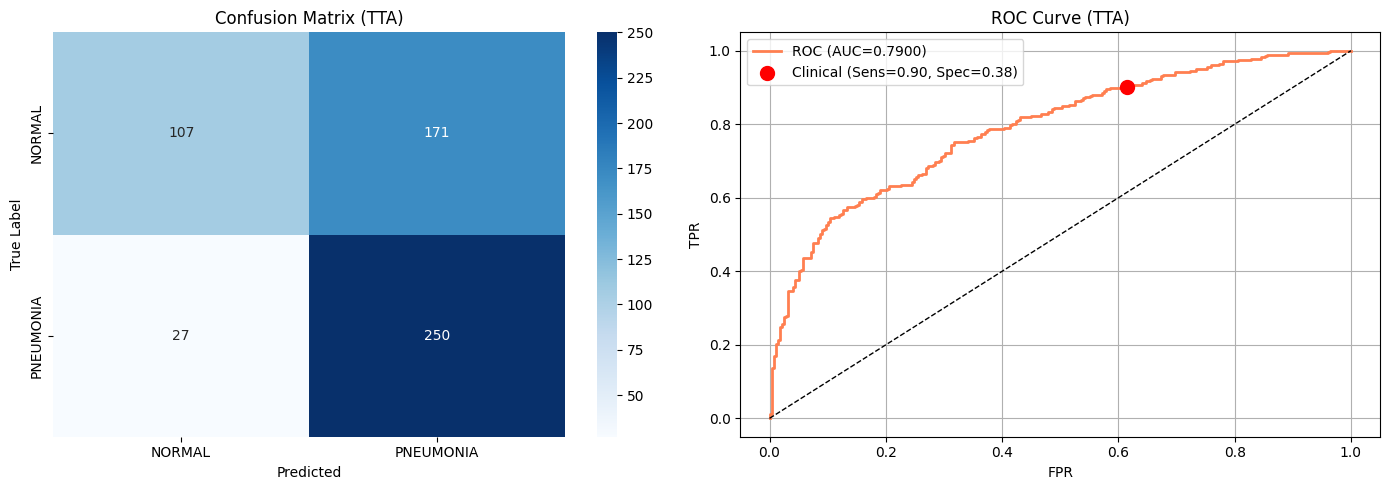

Results saved to: c:\\2026\\PneumoFusionNet\\mimic\\main\\dataset\outputs\Phase_1_Scaleup_PA_v2


In [13]:
# --- CELL 12: Confusion Matrix & ROC Curve ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title('Confusion Matrix (TTA)')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted')

# ROC Curve
axes[1].plot(fpr, tpr, color='coral', lw=2, label=f'ROC (AUC={auc:.4f})')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].scatter([1-spec],[sens], color='red', s=100, zorder=5,
                label=f'Clinical (Sens={sens:.2f}, Spec={spec:.2f})')
axes[1].set_title('ROC Curve (TTA)')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'results_scaleup_v2.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Results saved to: {SAVE_DIR}')

In [14]:
# --- CELL 13: Save Final Results JSON ---
results = {
    'model': 'Phase 1 Scaleup v2 (All Fixes)',
    'fixes_applied': [
        'No horizontal flip (anatomical laterality)',
        'Stratified split by per-subject label',
        'best_state saved in checkpoint (resume bug fix)',
        'Rotation reduced 10->5 degrees',
        'AMP mixed precision enabled',
        'Bbox merging (top-2 contours)'
    ],
    'dataset_size': len(df),
    'train_size': len(train_df),
    'val_size': len(val_df),
    'test_size': len(test_df),
    'auc': float(auc),
    'accuracy': float(acc),
    'f1': float(f1),
    'sensitivity': float(sens),
    'specificity': float(spec),
    'clinical_threshold': float(best_thresh),
    'youden_threshold': float(youden_thresh),
    'tta_views': TTA_VIEWS,
    'best_val_auc': float(best_auc),
    'backbone': BACKBONE_WEIGHTS,
    'img_size': IMG_SIZE,
    'amp_enabled': USE_AMP,
}
with open(os.path.join(SAVE_DIR, 'results_scaleup_v2.json'), 'w') as f:
    json.dump(results, f, indent=2)
print('Results saved:')
for k,v in results.items():
    print(f'  {k}: {v}')

Results saved:
  model: Phase 1 Scaleup v2 (All Fixes)
  fixes_applied: ['No horizontal flip (anatomical laterality)', 'Stratified split by per-subject label', 'best_state saved in checkpoint (resume bug fix)', 'Rotation reduced 10->5 degrees', 'AMP mixed precision enabled', 'Bbox merging (top-2 contours)']
  dataset_size: 3763
  train_size: 2642
  val_size: 566
  test_size: 555
  auc: 0.7899903903591928
  accuracy: 0.6432432432432432
  f1: 0.7163323782234956
  sensitivity: 0.9025270758122743
  specificity: 0.38489208633093525
  clinical_threshold: 0.2879210114479065
  youden_threshold: 0.6689071655273438
  tta_views: 10
  best_val_auc: 0.8322838580709646
  backbone: densenet121-res224-mimic_nb
  img_size: 320
  amp_enabled: True
